## Plot of the funciton

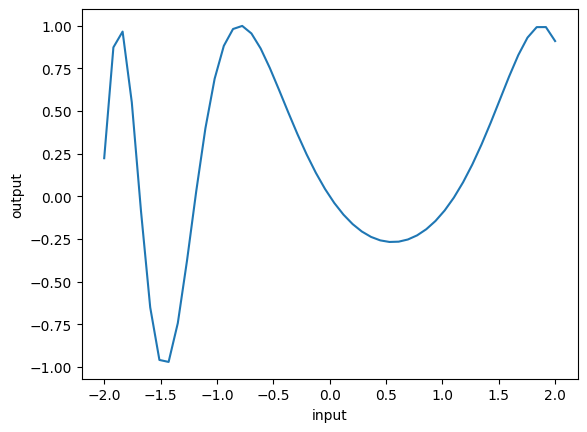

In [9]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("function_approximation.csv",delimiter=',')
input = data[:,0]
output = data[:,1]

plt.plot(input,output)
plt.xlabel("input")
plt.ylabel("output")
plt.show()

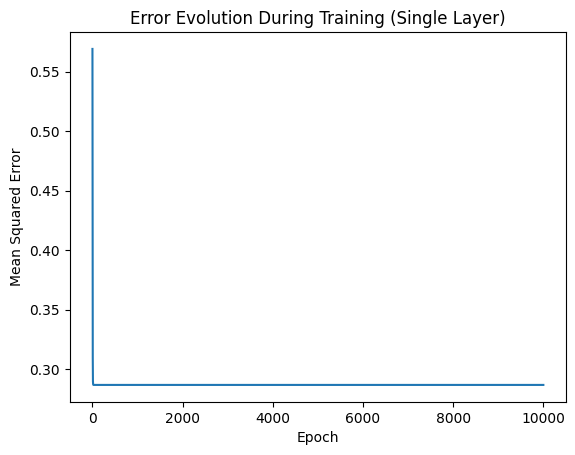

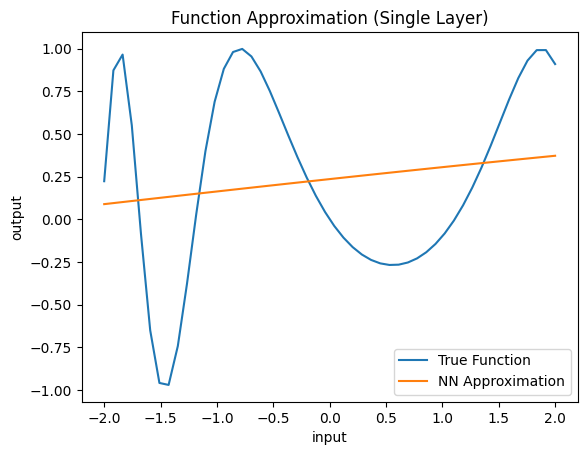

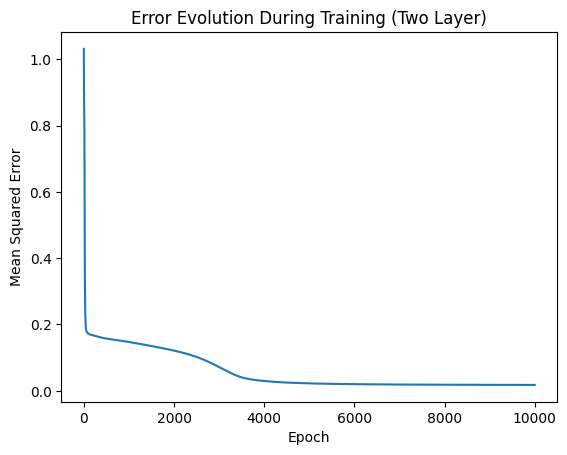

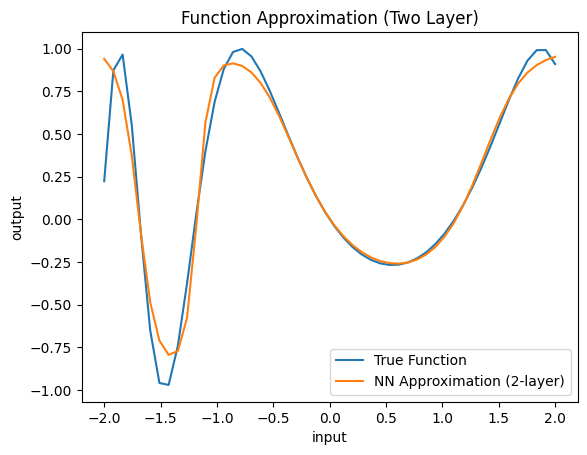

In [ ]:

class SingleLayerNet:
    def __init__(self):
        self.w = np.random.randn()
        self.b = np.random.randn()
    def activation(self, x):
        return np.tanh(x)
    def activation_deriv(self, x):
        return 1 - np.tanh(x)**2
    def forward(self, x):
        return self.activation(self.w * x + self.b)
    def train(self, x, y, lr=0.1, epochs=10000):
        errors = []
        for epoch in range(epochs):
            y_pred = self.forward(x)
            error = np.mean((y - y_pred)**2)
            errors.append(error)
            # Gradients
            dE_dy = -2 * (y - y_pred) / len(x)
            dy_dz = self.activation_deriv(self.w * x + self.b)
            dz_dw = x
            dz_db = 1
            grad_w = np.sum(dE_dy * dy_dz * dz_dw)
            grad_b = np.sum(dE_dy * dy_dz * dz_db)
            # Update weights
            self.w -= lr * grad_w
            self.b -= lr * grad_b
        return errors

# Train the network
np.random.seed(42)
net = SingleLayerNet()
errors = net.train(input, output, lr=0.1, epochs=10000)

plt.figure()
plt.plot(errors)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Error Evolution During Training (Single Layer)")
plt.show()

plt.figure()
plt.plot(input, output, label="True Function")
plt.plot(input, net.forward(input), label="NN Approximation")
plt.xlabel("input")
plt.ylabel("output")
plt.title("Function Approximation (Single Layer)")
plt.legend()
plt.show()

# Task 4c: Add another hidden layer (2-layer network)
class TwoLayerNet:
    def __init__(self, hidden_dim=5):
        self.w1 = np.random.randn(hidden_dim)
        self.b1 = np.random.randn(hidden_dim)
        self.w2 = np.random.randn(hidden_dim)
        self.b2 = np.random.randn()
    def activation(self, x):
        return np.tanh(x)
    def activation_deriv(self, x):
        return 1 - np.tanh(x)**2
    def forward(self, x):
        # x is a scalar or 1D array 
        z1 = self.w1 * x + self.b1
        a1 = self.activation(z1)
        z2 = np.dot(a1, self.w2) + self.b2 
        return self.activation(z2)
    def predict(self, x):
        # x is a 1D array of inputs
        return np.array([self.forward(xi) for xi in x])
    def train(self, x, y, lr=0.1, epochs=10000):
        errors = []
        for epoch in range(epochs):
            y_pred = self.predict(x)
            error = np.mean((y - y_pred)**2)
            errors.append(error)
            # Backpropagation for each sample
            grad_w1 = np.zeros_like(self.w1)
            grad_b1 = np.zeros_like(self.b1)
            grad_w2 = np.zeros_like(self.w2)
            grad_b2 = 0.0
            for xi, yi in zip(x, y):
                # Forward pass
                z1 = self.w1 * xi + self.b1
                a1 = self.activation(z1)
                z2 = np.dot(a1, self.w2) + self.b2
                y_pred_i = self.activation(z2)
                # Gradients
                dE_dy = -2 * (yi - y_pred_i)
                dy_dz2 = self.activation_deriv(z2)
                dz2_dw2 = a1
                dz2_db2 = 1
                grad_w2 += dE_dy * dy_dz2 * dz2_dw2
                grad_b2 += dE_dy * dy_dz2 * dz2_db2
                # Gradients for first layer
                dz2_da1 = self.w2
                da1_dz1 = self.activation_deriv(z1)
                grad_w1 += dE_dy * dy_dz2 * dz2_da1 * da1_dz1 * xi
                grad_b1 += dE_dy * dy_dz2 * dz2_da1 * da1_dz1
            # Average gradients
            grad_w1 /= len(x)
            grad_b1 /= len(x)
            grad_w2 /= len(x)
            grad_b2 /= len(x)
            # Update weights
            self.w2 -= lr * grad_w2
            self.b2 -= lr * grad_b2
            self.w1 -= lr * grad_w1
            self.b1 -= lr * grad_b1
        return errors

# Train the two-layer network
np.random.seed(42)
net2 = TwoLayerNet(hidden_dim=5)
errors2 = net2.train(input, output, lr=0.1, epochs=10000)

plt.figure()
plt.plot(errors2)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Error Evolution During Training (Two Layer)")
plt.show()

plt.figure()
plt.plot(input, output, label="True Function")
plt.plot(input, net2.predict(input), label="NN Approximation (2-layer)")
plt.xlabel("input")
plt.ylabel("output")
plt.title("Function Approximation (Two Layer)")
plt.legend()
plt.show()